# 🚦 Inference — HOG + RF / SVM
Load model `.joblib` và dự đoán từ ảnh bất kỳ.  
Pipeline extract feature **hoàn toàn khớp** với lúc train (`skimage` — không dùng `cv2`).

In [12]:
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize

## 1. Load model
Đổi `MODEL_PATH` sang model muốn dùng (`HOG_RandomForest_6x3`, `HOG_RandomForest_8x2`, `HOG_SVM_6x3`, `HOG_SVM_8x2`).

In [13]:
MODEL_PATH = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\models\HOG_RandomForest_6x3.joblib"

payload = joblib.load(MODEL_PATH)

model      = payload["model"]
le         = payload["label_encoder"]
HOG_PARAMS = payload["hog_params"]     # {'orientations', 'pixels_per_cell', 'cells_per_block', 'block_norm'}
IMAGE_SIZE = payload["image_size"]     # (128, 128)

print(f"✅ Model    : {type(model).__name__}")
print(f"✅ Classes  : {len(le.classes_)} lớp")
print(f"✅ HOG      : {HOG_PARAMS}")
print(f"✅ Img size : {IMAGE_SIZE}")

✅ Model    : RandomForestClassifier
✅ Classes  : 5 lớp
✅ HOG      : {'orientations': 9, 'pixels_per_cell': (6, 6), 'cells_per_block': (3, 3), 'block_norm': 'L2-Hys'}
✅ Img size : (128, 128)


## 2. Hàm extract feature — khớp 100% với lúc train

In [14]:
def extract_feature(image_path: str) -> np.ndarray:
    """Đọc ảnh → grayscale → resize → HOG. Giống hệt pipeline train."""
    img = imread(image_path)                              # skimage.io.imread
    gray = rgb2gray(img) if img.ndim == 3 else img        # rgb2gray nếu có màu
    gray = resize(gray, IMAGE_SIZE, anti_aliasing=True)   # resize về (128,128)
    feat = hog(gray, **HOG_PARAMS)                        # HOG params lấy từ payload
    return feat

## 3. Dự đoán 1 ảnh bất kỳ

🏷️  Dự đoán   : Nguyhiem
📊 Confidence : 51.38%

Top-3:
  Nguyhiem                            51.38%
  Hieulenh                            14.75%
  Cam                                 14.05%


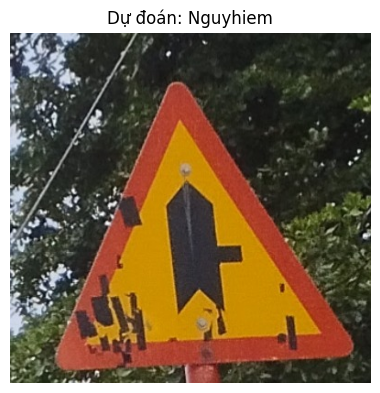

In [15]:
# ── Đổi đường dẫn ảnh vào đây ──
IMAGE_PATH = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test\Nguyhiem\Nguyhiem_3.jpeg"
# ────────────────────────────────

feat = extract_feature(IMAGE_PATH).reshape(1, -1)

pred_enc = model.predict(feat)[0]
label    = le.inverse_transform([pred_enc])[0]

has_proba = hasattr(model, "predict_proba")
proba     = model.predict_proba(feat)[0] if has_proba else None

print(f"🏷️  Dự đoán   : {label}")
if proba is not None:
    print(f"📊 Confidence : {proba[pred_enc]:.2%}")
    top3 = np.argsort(proba)[::-1][:3]
    print("\nTop-3:")
    for i in top3:
        print(f"  {le.inverse_transform([i])[0]:35s} {proba[i]:.2%}")

# Hiển thị ảnh
img_display = imread(IMAGE_PATH)
plt.figure(figsize=(4, 4))
plt.imshow(img_display, cmap="gray" if img_display.ndim == 2 else None)
plt.title(f"Dự đoán: {label}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. So sánh cả 4 model trên cùng 1 ảnh

In [16]:
MODELS_DIR = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\models"

MODEL_FILES = {
    "RF  6x3": "HOG_RandomForest_6x3.joblib",
    "RF  8x2": "HOG_RandomForest_8x2.joblib",
    "SVM 6x3": "HOG_SVM_6x3.joblib",
    "SVM 8x2": "HOG_SVM_8x2.joblib",
}

# ── Đổi đường dẫn ảnh vào đây ──
IMAGE_PATH = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test\Nguyhiem\Nguyhiem_3.jpeg"
# ────────────────────────────────

print(f"{'Model':<12} {'Dự đoán':<35} {'Confidence'}")
print("-" * 60)
for name, fname in MODEL_FILES.items():
    p = Path(MODELS_DIR) / fname
    if not p.exists():
        print(f"{name:<12} {'(file không tồn tại)':<35}")
        continue
    pl    = joblib.load(p)
    feat  = hog(resize(rgb2gray(imread(IMAGE_PATH)) if imread(IMAGE_PATH).ndim == 3
                       else imread(IMAGE_PATH), pl["image_size"], anti_aliasing=True),
                **pl["hog_params"]).reshape(1, -1)
    enc   = pl["model"].predict(feat)[0]
    lbl   = pl["label_encoder"].inverse_transform([enc])[0]
    conf  = (f"{pl['model'].predict_proba(feat)[0][enc]:.2%}"
             if hasattr(pl["model"], "predict_proba") else "N/A")
    print(f"{name:<12} {lbl:<35} {conf}")

Model        Dự đoán                             Confidence
------------------------------------------------------------
RF  6x3      Nguyhiem                            51.38%
RF  8x2      Nguyhiem                            57.51%
SVM 6x3      Nguyhiem                            N/A
SVM 8x2      Nguyhiem                            N/A


## 5. (Tùy chọn) Dự đoán hàng loạt — tính accuracy trên 1 thư mục có nhãn

Cấu trúc thư mục cần theo dạng: `folder/class_name/image.jpg`

In [17]:
from sklearn.metrics import accuracy_score, classification_report

TEST_DIR = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test"

test_root = Path(TEST_DIR)
img_exts  = {".jpg", ".jpeg", ".png", ".bmp"}

all_paths  = []
all_labels = []
for cls_dir in sorted(test_root.iterdir()):
    if not cls_dir.is_dir():
        continue
    for f in sorted(cls_dir.glob("*.*")):
        if f.suffix.lower() in img_exts:
            all_paths.append(f)
            all_labels.append(cls_dir.name)

print(f"Tìm thấy {len(all_paths)} ảnh, {len(set(all_labels))} lớp")

y_true = le.transform(all_labels)   # dùng le đã load ở Cell 1
y_pred = []

for path in all_paths:
    try:
        feat = extract_feature(str(path)).reshape(1, -1)
        y_pred.append(model.predict(feat)[0])
    except Exception:
        y_pred.append(-1)

y_pred = np.array(y_pred)
mask   = y_pred != -1

print(f"\nAccuracy: {accuracy_score(y_true[mask], y_pred[mask]):.4f}")
print(classification_report(y_true[mask], y_pred[mask], target_names=le.classes_))

Tìm thấy 155 ảnh, 5 lớp

Accuracy: 0.6968
              precision    recall  f1-score   support

         Cam       0.70      0.92      0.80        36
      Chidan       0.62      0.58      0.60        36
    Hieulenh       0.65      0.35      0.46        31
    Nguyhiem       0.85      1.00      0.92        29
         Phu       0.61      0.61      0.61        23

    accuracy                           0.70       155
   macro avg       0.69      0.69      0.68       155
weighted avg       0.69      0.70      0.68       155

